In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import scipy
import matplotlib.pyplot as plt

In [2]:
GRN_ROOT = './data'

In [3]:
GRN = pd.read_csv(f'{GRN_ROOT}/inferred_GRN.csv', index_col = 0)

In [4]:
GRN['Reg_name'] = np.where(GRN['Reg'] == -1, 'Inhibitory', 'Excitatory')

In [5]:
GRN

,TF,Gene,Reg,Reg_name
0,ADNP,A2M,-1.0,Inhibitory
1,ADNP2,A2M,1.0,Excitatory
2,AEBP1,A2M,-1.0,Inhibitory
4,AHR,A2M,-1.0,Inhibitory
6,AIRE,A2M,-1.0,Inhibitory
...,...,...,...,...
1057,ZNF92,ZZZ3,-1.0,Inhibitory
1061,ZSCAN16,ZZZ3,1.0,Excitatory
1064,ZSCAN21,ZZZ3,-1.0,Inhibitory
1065,ZSCAN22,ZZZ3,1.0,Excitatory


In [6]:
graph = nx.from_pandas_edgelist(GRN, source = 'TF', target='Gene', edge_attr='Reg_name', create_using = nx.DiGraph)

In [7]:
#nx.draw(graph)

In [8]:
PIP4K2C_graph_df = GRN[GRN['Gene'] == 'PIP4K2C']
PIP4K2C_graph = nx.from_pandas_edgelist(PIP4K2C_graph_df, source = 'TF', target='Gene', edge_attr='Reg_name', create_using = nx.DiGraph)

In [9]:
reg_type = nx.get_edge_attributes(PIP4K2C_graph,'Reg_name').values()
reg_type

dict_values(['Inhibitory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Inhibitory', 'Inhibitory', 'Inhibitory', 'Inhibitory', 'Excitatory', 'Excitatory', 'Inhibitory', 'Excitatory', 'Inhibitory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Inhibitory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Inhibitory', 'Inhibitory', 'Excitatory', 'Excitatory', 'Excitatory', 'Inhibitory', 'Inhibitory', 'Inhibitory', 'Inhibitory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Inhibitory', 'Excitatory', 'Inhibitory', 'Inhibitory', 'Inhibitory', 'Inhibitory', 'Excitatory', 'Excitatory', 'Inhibitory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Excitatory', 'Inhibitory', 'Excitatory', 'Excitatory', 'Excitatory', 'Inhibitory', 'Inhibitory', 'Inhibitory', 'Inhibitory', 'Excitatory', 'Inhibitory', 'Excitatory', 'Excitatory', 'Inhibi

In [10]:
#create a dictionary mapping reg type to colors
cmap = {
    'Inhibitory' : 'red',
    'Excitatory' : 'blue'
}

color_list = [cmap[reg_t] for reg_t in reg_type]

In [11]:
'PIP4K2C' in PIP4K2C_graph.nodes()

True

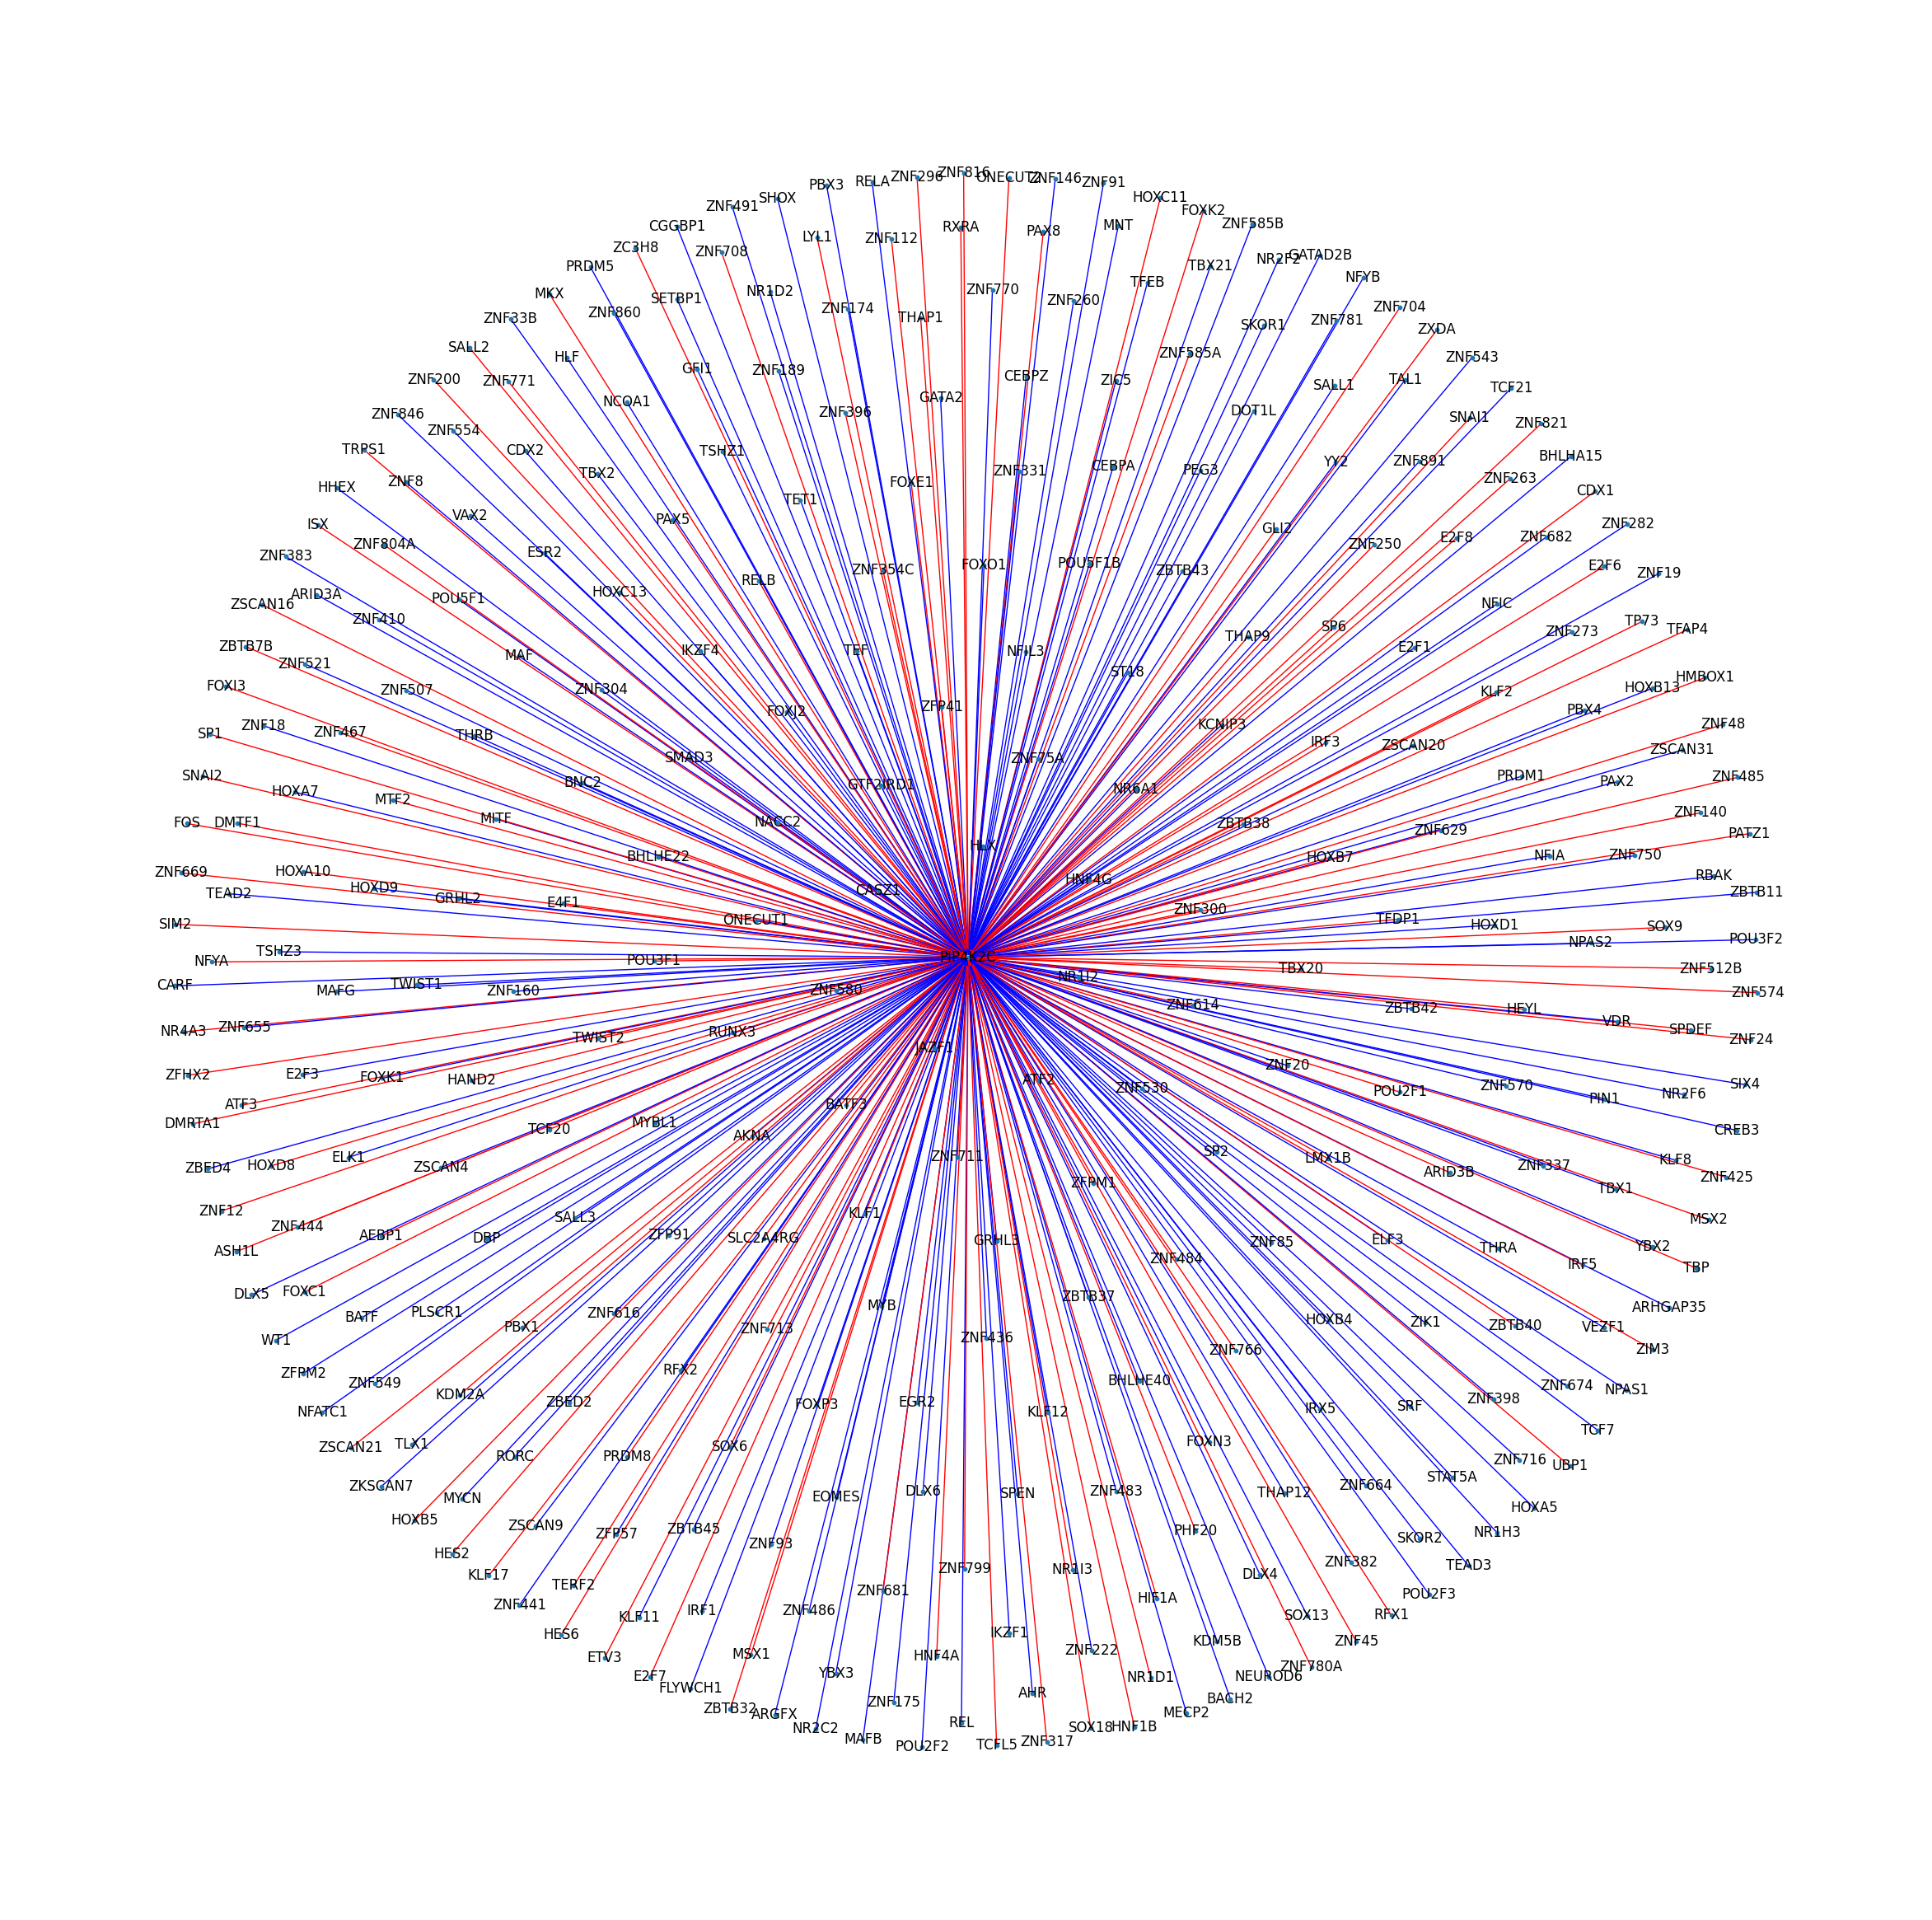

In [12]:
fig, ax = plt.subplots(figsize=(30,30))

layout = nx.arf_layout(PIP4K2C_graph)
nx.draw(PIP4K2C_graph,
        layout,
        edge_color= color_list,
        with_labels=True,
        node_size = 10)

In [13]:
len(PIP4K2C_graph.nodes())

352